<a href="https://colab.research.google.com/github/ENRIKO-18/D-DScience/blob/main/M3_P2_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Práctica 2</h1>
<h2>Regresión</h2>


<a href="https://colab.research.google.com/github/DCDPUAEM/DCDP/blob/main/03%20Machine%20Learning/notebooks/P2-Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


En esta práctica realizarás la tarea de regresión para predecir el precio de casas en el dataset [Ames Housing](https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset).

El dataset Ames Housing contiene información sobre ventas de viviendas en Ames, Iowa, entre 2006 y 2010. Incluye 80 variables (numéricas y categóricas) que describen características de las casas, como área habitable, calidad, año de construcción, y ubicación. La variable objetivo es SalePrice (precio de venta). Tiene 2,930 observaciones y es comúnmente usado para practicar modelos de regresión en machine learning.

El dataset:

In [1]:
import pandas as pd

url = "https://github.com/DCDPUAEM/DCDP/raw/main/03%20Machine%20Learning/data/AmesHousing.csv"
df = pd.read_csv(url)
df.drop(columns=["Order","PID"], inplace=True)
df


,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


🔴 Verifica si hay datos faltantes, en caso de que sí, realiza la imputación usando la estrategia que elijas.

In [2]:
pd.set_option('display.max_rows', None)

In [3]:
faltantes=df.isna().sum()
print(faltantes,"\n")
print(f"Faltantes totales:{faltantes.sum()}")

MS SubClass           0
MS Zoning             0
Lot Frontage        490
Lot Area              0
Street                0
Alley              2732
Lot Shape             0
Land Contour          0
Utilities             0
Lot Config            0
Land Slope            0
Neighborhood          0
Condition 1           0
Condition 2           0
Bldg Type             0
House Style           0
Overall Qual          0
Overall Cond          0
Year Built            0
Year Remod/Add        0
Roof Style            0
Roof Matl             0
Exterior 1st          0
Exterior 2nd          0
Mas Vnr Type       1775
Mas Vnr Area         23
Exter Qual            0
Exter Cond            0
Foundation            0
Bsmt Qual            80
Bsmt Cond            80
Bsmt Exposure        83
BsmtFin Type 1       80
BsmtFin SF 1          1
BsmtFin Type 2       81
BsmtFin SF 2          1
Bsmt Unf SF           1
Total Bsmt SF         1
Heating               0
Heating QC            0
Central Air           0
Electrical      

# PREPROCESMIENTO

In [8]:
#Creo una copia del DATAFRAME
df2=df.copy()

1. Estoy considerando borrar aquellas columnas con mas de1000 datos faltantes (34% faltantes).

In [9]:
#Ubral en 60%
#umbral =0.6
#porcent_faltantes=df2.isna().mean()
columnas_borrar=faltantes[faltantes>1000].index
df2.drop(columns=columnas_borrar, inplace=True)
print(df2.shape)

(2930, 74)


In [10]:
#Columnas elimmindas
print(columnas_borrar)

Index(['Alley', 'Mas Vnr Type', 'Fireplace Qu', 'Pool QC', 'Fence',
       'Misc Feature'],
      dtype='object')


2. Aplicar imputación en columnas con faltantes:
* Para los datos nominales ("object") considero imputación con valor mas frecuente (moda).
* Para datos numéricos (float64) considero imputación con mediana.

In [17]:
#Identifo las columnas con datos faltantes
columnas_faltantes = df2.columns[df2.isna().any()]
print(columnas_faltantes)

Index(['Lot Frontage', 'Mas Vnr Area', 'Bsmt Qual', 'Bsmt Cond',
       'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2',
       'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Electrical',
       'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Type', 'Garage Yr Blt',
       'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual',
       'Garage Cond'],
      dtype='object')


In [18]:
#ver el tipo de dato que tienen
print(df2[columnas_faltantes].dtypes)

Lot Frontage      float64
Mas Vnr Area      float64
Bsmt Qual          object
Bsmt Cond          object
Bsmt Exposure      object
BsmtFin Type 1     object
BsmtFin SF 1      float64
BsmtFin Type 2     object
BsmtFin SF 2      float64
Bsmt Unf SF       float64
Total Bsmt SF     float64
Electrical         object
Bsmt Full Bath    float64
Bsmt Half Bath    float64
Garage Type        object
Garage Yr Blt     float64
Garage Finish      object
Garage Cars       float64
Garage Area       float64
Garage Qual        object
Garage Cond        object
dtype: object


In [22]:
for col in columnas_faltantes:
    if df2[col].dtype == 'object':
        # Imputación con la moda
        df2[col].fillna(df2[col].mode()[0], inplace=True)
    else:
        # Imputación con la mediana
        df2[col].fillna(df2[col].median(), inplace=True)

print(df2[columnas_faltantes].isna().sum()) #Para verificar que ya no tenga faltantes

Lot Frontage      0
Mas Vnr Area      0
Bsmt Qual         0
Bsmt Cond         0
Bsmt Exposure     0
BsmtFin Type 1    0
BsmtFin SF 1      0
BsmtFin Type 2    0
BsmtFin SF 2      0
Bsmt Unf SF       0
Total Bsmt SF     0
Electrical        0
Bsmt Full Bath    0
Bsmt Half Bath    0
Garage Type       0
Garage Yr Blt     0
Garage Finish     0
Garage Cars       0
Garage Area       0
Garage Qual       0
Garage Cond       0
dtype: int64


<ipython-input-22-63a9cf1311b9>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2[col].fillna(df2[col].median(), inplace=True)


🔴 Usando el método `describe` del dataframe, observa los rangos de cada variable numérica.

* ¿Cuál es la variable con los valores más altos?
* ¿Cuál es la variable con el rango de valores más angosto?

In [26]:
pd.set_option('display.max_columns', None)
df2.describe()

,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,57.387372,69.019795,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.096928,442.604778,49.705461,559.230717,1051.593515,1159.557679,335.455973,4.676792,1499.690444,0.431058,0.061092,1.566553,0.379522,2.854266,1.044369,6.443003,0.599317,1978.179522,1.766894,472.822184,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,42.638025,21.326422,7880.017759,1.411026,1.111537,30.245361,20.860286,178.634545,455.515036,169.142089,439.422500,440.541315,391.890885,428.395715,46.310510,505.508887,0.524762,0.245175,0.552941,0.502629,0.827731,0.214076,1.572964,0.647921,24.826620,0.760449,215.009876,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,20.000000,60.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,219.000000,793.000000,876.250000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1962.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,466.000000,990.000000,1084.000000,0.000000,0.000000,1442.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,70.000000,78.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,162.750000,734.000000,0.000000,801.750000,1301.500000,1384.000000,703.750000,0.000000,1742.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


¿Cuál es la variable con los valores más altos?

**Lot Area**

¿Cuál es la variable con el rango de valores más angosto?

**Bsmt Half Bath** & **Half Bath**- 2


Examina la correlación entre variables. **Observa que aquí está también la variable target**

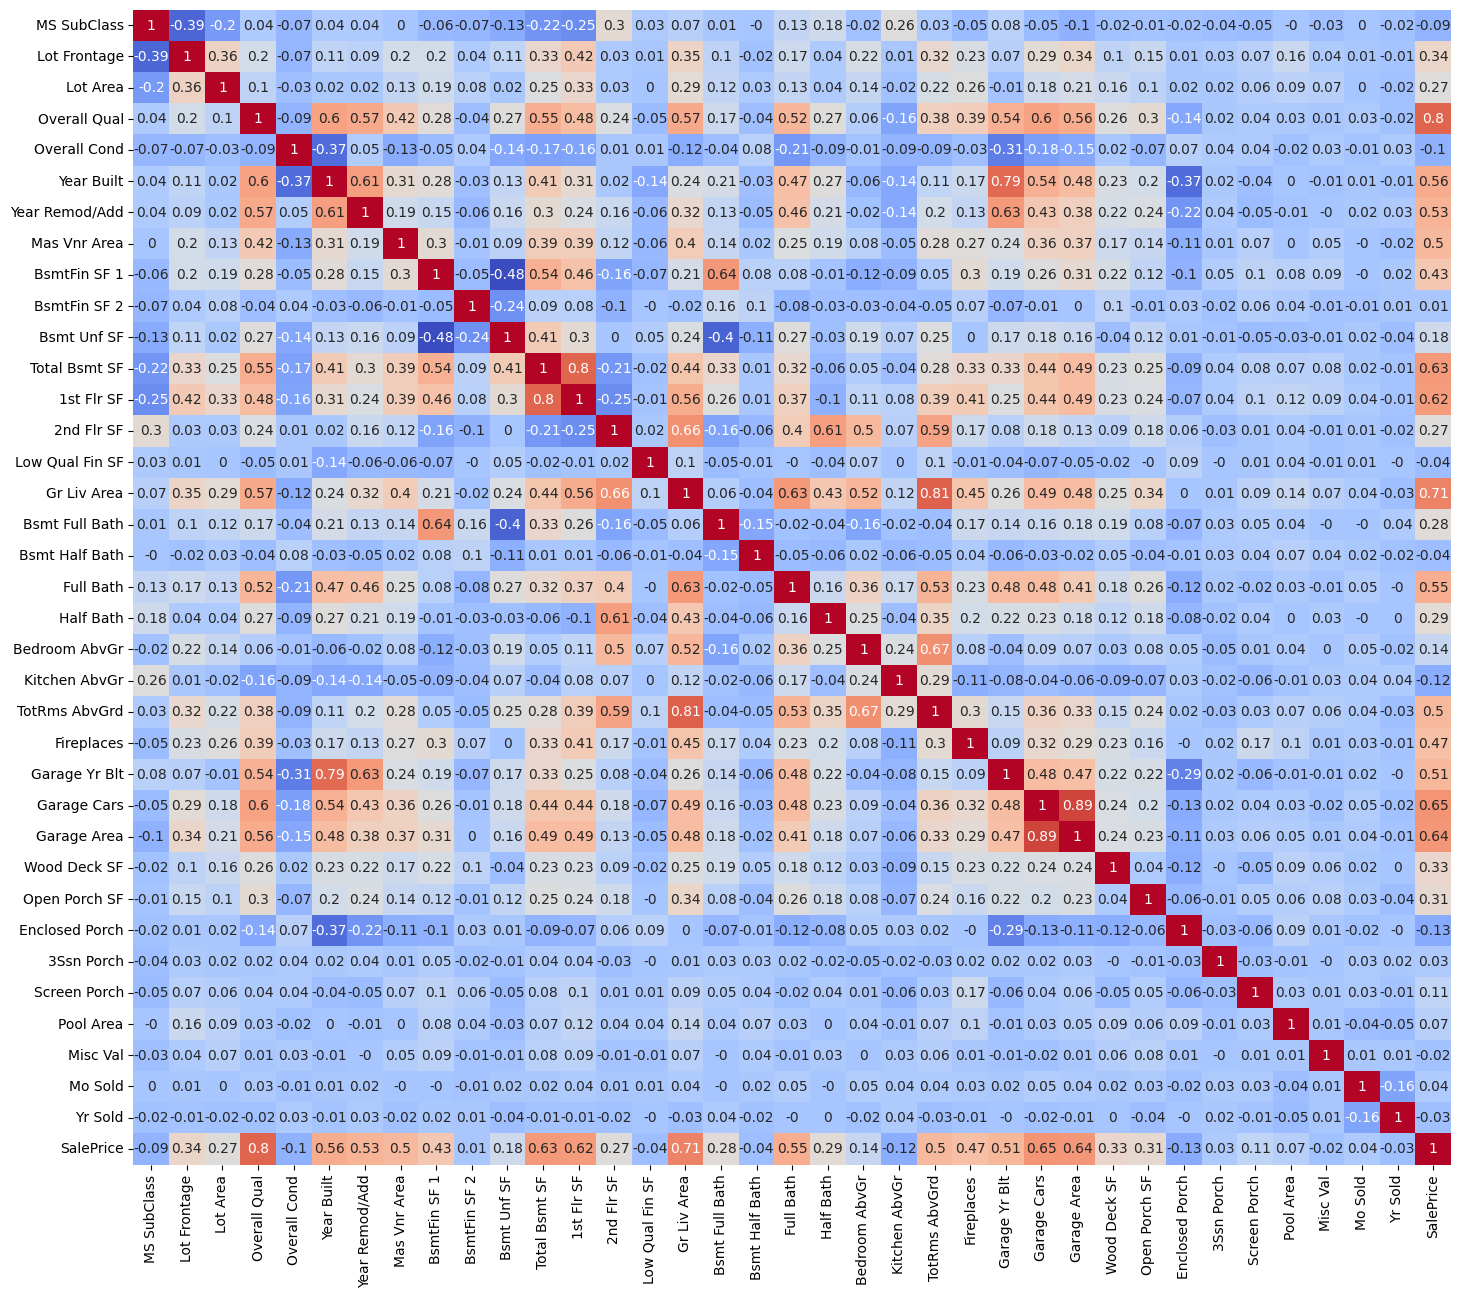

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

df_numeric = df2.select_dtypes(include=['int64', 'float64'])  # Sólo queremos considerar las variables numéricas para este análisis
corr_mat = df_numeric.corr().round(2)

plt.figure(figsize=(17, 15))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm',cbar=False)
plt.show()

🔴 Responde aquí: ¿Cuáles son las parejas de variables que presentan el **problema** de multicolinealidad?

* Garage Cars/Garage Area -(0.89)
* Gr Liv Area/ TotRms AbvGrd -(0.81)
* 1st Flr SF/ Total Bsmt SF	-(0.8)

De cada grupo de variables con multicolinealidad quédate sólo con una de ellas y elimina la(s) otra(s).

In [29]:
df2.drop(columns=["Garage Cars","Gr Liv Area","1st Flr SF"], inplace=True)

KeyError: "['Garage Cars', 'Gr Liv Area', '1st Flr SF'] not found in axis"

In [30]:
print(df2.shape)

(2930, 71)


🔴 Observa las relaciones entre las variables numéricas predictoras y la variable target:

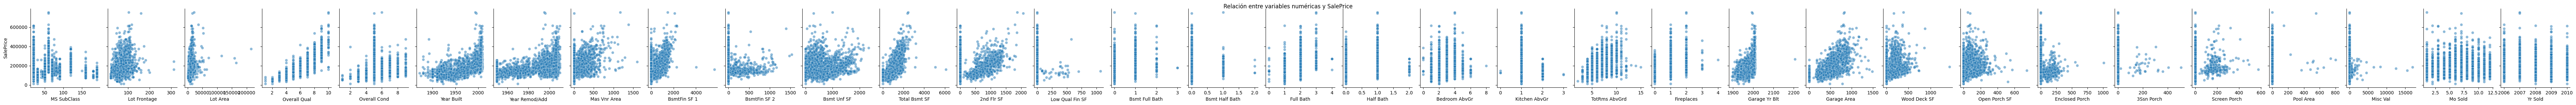

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo columnas numéricas
numeric_cols = df2.select_dtypes(include=['int64', 'float64']).columns

# Crear pair plot (relación entre variables numéricas y 'SalePrice')
sns.pairplot(
    data=df2[numeric_cols],
    y_vars=['SalePrice'],          # Variable objetivo
    x_vars=numeric_cols.drop('SalePrice'),  # Todas las numéricas excepto target
    height=3,
    aspect=0.8,
    plot_kws={'alpha': 0.5}
)

plt.suptitle('Relación entre variables numéricas y SalePrice', y=1.02)
plt.show()

🔴 Elige una variable que consideres que tiene mucha relación con la variable target y eliminala.

In [33]:
df2.drop(columns=["Overall Qual"], inplace=True)

🔴 Aplica la codificación *one-hot* a las variables categóricas. Usa la opción `drop_first=True` para evitar la multicolinealidad en las variables binarias resultantes.

In [34]:
#Identificación de vairbales categóricas
cat_col = df2.select_dtypes(include=['object']).columns
#One hot
df_oneH = pd.get_dummies(df2, columns=cat_col, drop_first=True)
df_oneH.head()

,MS SubClass,Lot Frontage,Lot Area,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,2nd Flr SF,Low Qual Fin SF,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM,Street_Pave,Lot Shape_IR2,Lot Shape_IR3,Lot Shape_Reg,Land Contour_HLS,Land Contour_Low,Land Contour_Lvl,Utilities_NoSeWa,Utilities_NoSewr,Lot Config_CulDSac,Lot Config_FR2,Lot Config_FR3,Lot Config_Inside,Land Slope_Mod,Land Slope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_GrnHill,Neighborhood_IDOTRR,Neighborhood_Landmrk,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition 1_Feedr,Condition 1_Norm,Condition 1_PosA,Condition 1_PosN,Condition 1_RRAe,Condition 1_RRAn,Condition 1_RRNe,Condition 1_RRNn,Condition 2_Feedr,Condition 2_Norm,Condition 2_PosA,Condition 2_PosN,Condition 2_RRAe,Condition 2_RRAn,Condition 2_RRNn,Bldg Type_2fmCon,Bldg Type_Duplex,Bldg Type_Twnhs,Bldg Type_TwnhsE,House Style_1.5Unf,House Style_1Story,House Style_2.5Fin,House Style_2.5Unf,House Style_2Story,House Style_SFoyer,House Style_SLvl,Roof Style_Gable,Roof Style_Gambrel,Roof Style_Hip,Roof Style_Mansard,Roof Style_Shed,Roof Matl_CompShg,Roof Matl_Membran,Roof Matl_Metal,Roof Matl_Roll,Roof Matl_Tar&Grv,Roof Matl_WdShake,Roof Matl_WdShngl,Exterior 1st_AsphShn,Exterior 1st_BrkComm,Exterior 1st_BrkFace,Exterior 1st_CBlock,Exterior 1st_CemntBd,Exterior 1st_HdBoard,Exterior 1st_ImStucc,Exterior 1st_MetalSd,Exterior 1st_Plywood,Exterior 1st_PreCast,Exterior 1st_Stone,Exterior 1st_Stucco,Exterior 1st_VinylSd,Exterior 1st_Wd Sdng,Exterior 1st_WdShing,Exterior 2nd_AsphShn,Exterior 2nd_Brk Cmn,Exterior 2nd_BrkFace,Exterior 2nd_CBlock,Exterior 2nd_CmentBd,Exterior 2nd_HdBoard,Exterior 2nd_ImStucc,Exterior 2nd_MetalSd,Exterior 2nd_Other,Exterior 2nd_Plywood,Exterior 2nd_PreCast,Exterior 2nd_Stone,Exterior 2nd_Stucco,Exterior 2nd_VinylSd,Exterior 2nd_Wd Sdng,Exterior 2nd_Wd Shng,Exter Qual_Fa,Exter Qual_Gd,Exter Qual_TA,Exter Cond_Fa,Exter Cond_Gd,Exter Cond_Po,Exter Cond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Bsmt Qual_Fa,Bsmt Qual_Gd,Bsmt Qual_Po,Bsmt Qual_TA,Bsmt Cond_Fa,Bsmt Cond_Gd,Bsmt Cond_Po,Bsmt Cond_TA,Bsmt Exposure_Gd,Bsmt Exposure_Mn,Bsmt Exposure_No,BsmtFin Type 1_BLQ,BsmtFin Type 1_GLQ,BsmtFin Type 1_LwQ,BsmtFin Type 1_Rec,BsmtFin Type 1_Unf,BsmtFin Type 2_BLQ,BsmtFin Type 2_GLQ,BsmtFin Type 2_LwQ,BsmtFin Type 2_Rec,BsmtFin Type 2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Heating QC_Fa,Heating QC_Gd,Heating QC_Po,Heating QC_TA,Central Air_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Kitchen Qual_Fa,Kitchen Qual_Gd,Kitchen Qual_Po,Kitchen Qual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sal,Functional_Sev,Functional_Typ,Garage Type_Attchd,Garage Type_Basment,Garage Type_BuiltIn,Garage Type_CarPort,Garage Type_Detchd,Garage Finish_RFn,Garage Finish_Unf,Garage Qual_Fa,Garage Qual_Gd,Garage Qual_Po,Garage Qual_TA,Garage Cond_Fa,Garage Cond_Gd,Garage Cond_Po,Garage Cond_TA,Paved Drive_P,Paved Drive_Y,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Con

In [35]:
print(df_oneH.shape)

(2930, 239)


# REGRESIÓN

🔴 Realiza las siguientes acciones:

1. Haz una división train/test con la proporción 80%/20%.
2. Define un pipeline con los siguientes pasos:
 * Escalador
 * Selector de features
 * Polinomial Features, elige el grado que consideres necesario (si eliges un valor muy alto puede ser muy tardado el proceso).
 * Algoritmo de regresión lineal ElasticNet.
3. Entrena con el conjunto de entrenamiento y muestra el coeficiente $R^2$ en el conjunto de entrenamiento y prueba.
4. Obten las predicciones para el conjunto de prueba.
5. Evalua el rendimiento usando las métricas MAE, MAPE y [RMSE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html). Esta última no la hemos usado hasta el momento, es otra medición de qué tan alejados están las predicciones del valor real, entre más bajo es mejor.

**1.   División de los datos**


In [41]:
from sklearn.model_selection import train_test_split

df3=df_oneH.copy()  # copia del dataframe preprocesado
X = df3.drop(columns=["SalePrice"])
y = df3["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=9)

**2- Define un pipeline**

In [50]:
#carga de librerias
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error,mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

In [39]:
#declaracion del PIPELINE
pipe=Pipeline([("Escalador", StandardScaler()),("Selector", SelectKBest(score_func=f_regression, k=20)),("Polinomio", PolynomialFeatures(degree=2, include_bias=False)),("ElasticN", ElasticNet(alpha=1,l1_ratio=0.5))])

**3. Entrenamiento**

**4. Predicción.**

In [42]:
pipe.fit(X_train, y_train)

#Predicciones
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

#Metrica R2
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"R2 en el conjunto de entrenamiento: {r2_train}")
print(f"R2 en el conjunto de prueba: {r2_test}")

R2 en el conjunto de entrenamiento: 0.8551733239141613
R2 en el conjunto de prueba: 0.8081546365696058


**5. Evaluación de rendimiento**

In [54]:
# MAE
mae = np.round(mean_absolute_error(y_test,y_test_pred),3)

# MAPE
mape = np.round(mean_absolute_percentage_error(y_test,y_test_pred),3)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"MAE  (Error Absoluto Medio): {mae}")
print(f"MAPE (Error Porcentual Medio): {mape}%")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.3f}")

MAE  (Error Absoluto Medio): 21703.699
MAPE (Error Porcentual Medio): 0.135%
RMSE (Raíz del Error Cuadrático Medio): 33681.397


🔴 Repite el experimento del punto anterior cambiando el algoritmo por alguno de los siguientes:
* [SVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html)
* [kNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)

In [67]:
from sklearn.svm import SVR

**Nuevo PIEPELINE**

In [73]:
pipe2= Pipeline([("Escalador", StandardScaler()),("Selector", SelectKBest(score_func=f_regression, k=20)),('svr',SVR(kernel='rbf', C=100, epsilon=0.1))])

**Enrtenamiento y predicción**

In [74]:
# Entrenar el modelo
pipe2.fit(X_train, y_train)

#Predicciones
y_train_pred = pipe2.predict(X_train)
y_test_pred = pipe2.predict(X_test)

#Metrica R2
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"R2 en el conjunto de entrenamiento: {r2_train}")
print(f"R2 en el conjunto de prueba: {r2_test}")

R2 en el conjunto de entrenamiento: 0.1950877406762317
R2 en el conjunto de prueba: 0.2096774498643048


In [75]:
# MAE
mae = np.round(mean_absolute_error(y_test,y_test_pred),3)

# MAPE
mape = np.round(mean_absolute_percentage_error(y_test,y_test_pred),3)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"MAE  (Error Absoluto Medio): {mae}")
print(f"MAPE (Error Porcentual Medio): {mape}%")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.3f}")

MAE  (Error Absoluto Medio): 41658.575
MAPE (Error Porcentual Medio): 0.233%
RMSE (Raíz del Error Cuadrático Medio): 68362.295
